In [1]:
# STEP 0: Load Dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sample data.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     1565 non-null   str    
 1   Open     1565 non-null   float64
 2   High     1565 non-null   float64
 3   Low      1565 non-null   float64
 4   Close    1565 non-null   float64
 5   Volume   1565 non-null   int64  
 6   OpenInt  1565 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 85.7 KB


In [2]:
# STEP 1: Feature Engineering

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# Sort by date (important for time series)
df = df.sort_values(by="Date")

# Create new features (lag features)
df["Prev_Close"] = df["Close"].shift(1)
df["Prev_Open"] = df["Open"].shift(1)

# Create target (next day close price)
df["Target"] = df["Close"].shift(-1)

# Drop missing values created by shifting
df = df.dropna()

df.head()

,Date,Open,High,Low,Close,Volume,OpenInt,Prev_Close,Prev_Open,Target
1,2010-07-22,24.644,24.644,24.362,24.487,18031,0,23.946,24.333,24.507
2,2010-07-23,24.759,24.759,24.314,24.507,8897,0,24.487,24.644,24.595
3,2010-07-26,24.624,24.624,24.449,24.595,19443,0,24.507,24.759,24.517
4,2010-07-27,24.477,24.517,24.431,24.517,8456,0,24.595,24.624,24.431
5,2010-07-28,24.477,24.517,24.352,24.431,4967,0,24.517,24.477,24.256


In [3]:
# STEP 2: Feature Selection and Train-Test Split

from sklearn.model_selection import train_test_split

# Select features
X = df[["Open", "High", "Low", "Volume", "Prev_Close", "Prev_Open"]]
y = df["Target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# Insight:
# shuffle=False is important for time series data
# maintains chronological order

Training shape: (1250, 6)
Testing shape: (313, 6)


In [4]:
# STEP 3: Model Training

from sklearn.linear_model import LinearRegression

# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [5]:
# STEP 4: Prediction and Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# Insight:
# MAE shows average prediction error
# RMSE penalizes larger errors more

MAE: 0.39605624475318546
RMSE: 0.5148887803027341


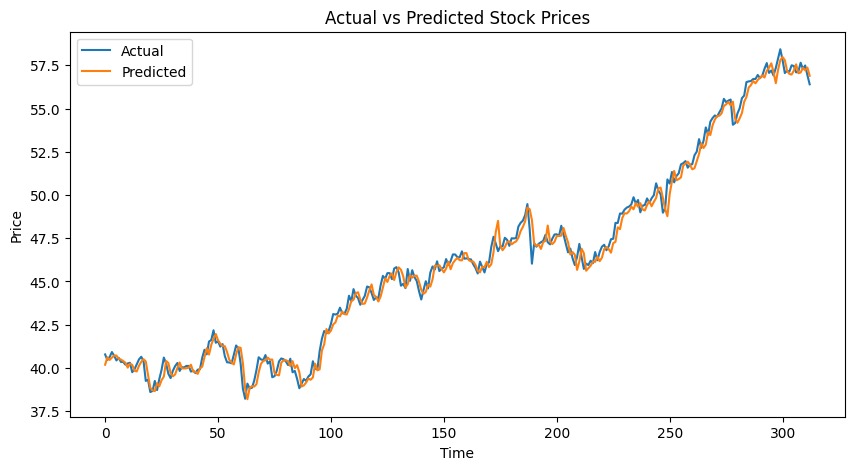

In [6]:
# STEP 5: Visualization of Actual vs Predicted

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Conclusion

In this project, a machine learning model was developed to predict stock closing prices using historical data.

Time series data was transformed into a supervised learning problem by creating lag features such as previous day open and close prices. Linear Regression was used to model the relationship between input features and the target variable.

The model was evaluated using regression metrics such as MAE and RMSE, and results showed that the model was able to capture general price trends effectively.

This project demonstrates how basic machine learning techniques can be applied to time series data using feature engineering, without relying on complex forecasting models.